<a href="https://colab.research.google.com/github/DanialNayyar/Mathematical-Modelling-Mini-Projects/blob/main/mathematical_methods/chapter1_preliminary_algebra/polynomial_root_finder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Polynomial Root Finder

For a given polynomial with coeffecients given-
1.   Evaluate the polynomial
2.   Plot the curve
3.   Calculate the roots
4.   Classify the roots as real, repeated or complex
5.   Subsitute the roots into the polynomial
6.   Calculate the residual errors
7.   Handle linear, quadratic, and cubic examples



# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Evaluating the Polynomial (and formatting it)

In [2]:

def polynomial_formatter(coefficients):
  degree = len(coefficients) - 1
  terms = []

  for index, coefficient in enumerate(coefficients):
    power = degree - index

    if coefficient == 0:
      continue

    abs_coefficient = abs(coefficient)

    if power == 0: #constant
      term = f"{abs_coefficient:g}"

    elif power == 1: #linear
      if abs_coefficient == 1:
        term = f"x"
      else:
        term = f"{abs_coefficient:g}x"

    else: #quadratic, cubic etc
      if abs_coefficient == 1:
        term = f"x^{power}"
      else:
        term = f"{abs_coefficient:g}x^{power}"


    if len(terms) == 0:
      if coefficient < 0:
        term_signed = f"-{term}"
      else:
        term_signed = term

    else:
      if coefficient < 0:
        term_signed = f"-{term}"
      else:
        term_signed = f"+{term}"

    terms.append(term_signed)

  if len(terms) == 0:
    return "0"

  else:
    y_equation = "".join(terms)

  return y_equation

test_1 = polynomial_formatter([1,-5,6])

test_2 = polynomial_formatter([1,2,1])

test_3 = polynomial_formatter([3,0,-1,7])

test_4 =polynomial_formatter([-1,0,4])

test_5 =polynomial_formatter([0,0,0])

print(test_1)
print(test_2)
print(test_3)
print(test_4)
print(test_5)

x^2-5x+6
x^2+2x+1
3x^3-x+7
-x^2+4
0


In [3]:
polynomial_input = input("Enter polynomial (coefficients only) space sepearated: ")
x_values_input = input("Enter x values space separated: ")


def evaluating_polynomial(polynomial_input, x_values_input, polynomial_formatter):
  # Coefficients
  coefficients_input = polynomial_input.split()
  coefficients = []
  for i in coefficients_input:
    i = float(i)

    coefficients.append(i)

  # Degrees and Powers
  degree = len(coefficients) - 1
  powers = []
  for index, coefficient in enumerate(coefficients):
    power = degree - index
    powers.append(power)


  # Equation
  equation = []
  for coefficient, power in zip(coefficients, powers):
    equation.append((coefficient, power))


  # X Values

  x_values_input = x_values_input.split()
  x_values = []
  for i in x_values_input:
    i = float(i)

    x_values.append(i)


  # Subsituting the x values into the equation
  answers_dict = {}

  for x_value in x_values:
    ans = 0

    for coefficient, power in equation:

      ans += coefficient * (x_value ** power)



    answers_dict[x_value] = ans


  y_equation_helped = polynomial_formatter(coefficients)




  return f"Coefficients are: {coefficients}", f"Degree of the Polynomial is: {degree}", f"The powers of each terms are: {powers}", f"X Values: {x_values}", f"Polynomial result when x values are substituted: {answers_dict}", f"Polynomial (formatted): {y_equation_helped} "



results = evaluating_polynomial(polynomial_input, x_values_input,polynomial_formatter)


for result in results:
  print(result)
  print()

Enter polynomial (coefficients only) space sepearated: 1 2 1
Enter x values space separated: 0 1 2 3 4 5 6 7 8 9
Coefficients are: [1.0, 2.0, 1.0]

Degree of the Polynomial is: 2

The powers of each terms are: [2, 1, 0]

X Values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]

Polynomial result when x values are substituted: {0.0: 1.0, 1.0: 4.0, 2.0: 9.0, 3.0: 16.0, 4.0: 25.0, 5.0: 36.0, 6.0: 49.0, 7.0: 64.0, 8.0: 81.0, 9.0: 100.0}

Polynomial (formatted): x^2+2x+1 



# 2. Plotting the Polynomial

In [4]:
def polynomial_evaluator(coefficients, x_values):
  # Degrees and Powers
  degree = len(coefficients) - 1
  powers = []
  for index, coefficient in enumerate(coefficients):
    power = degree - index
    powers.append(power)


  # Equation
  equation = []
  for coefficient, power in zip(coefficients, powers):
    equation.append((coefficient, power))

  # Subsituting the x values into the equation
  answers_dict = {}

  for x_value in x_values:
    ans = 0

    for coefficient, power in equation:

      ans += coefficient * (x_value ** power)


    answers_dict[x_value] = ans

  answers = []

  for v in answers_dict.values():
    answers.append(v)


  return answers


polynomial_evaluator([1,-5,6], [0,1.5,-122,3])

[6, 0.75, 15500, 0]

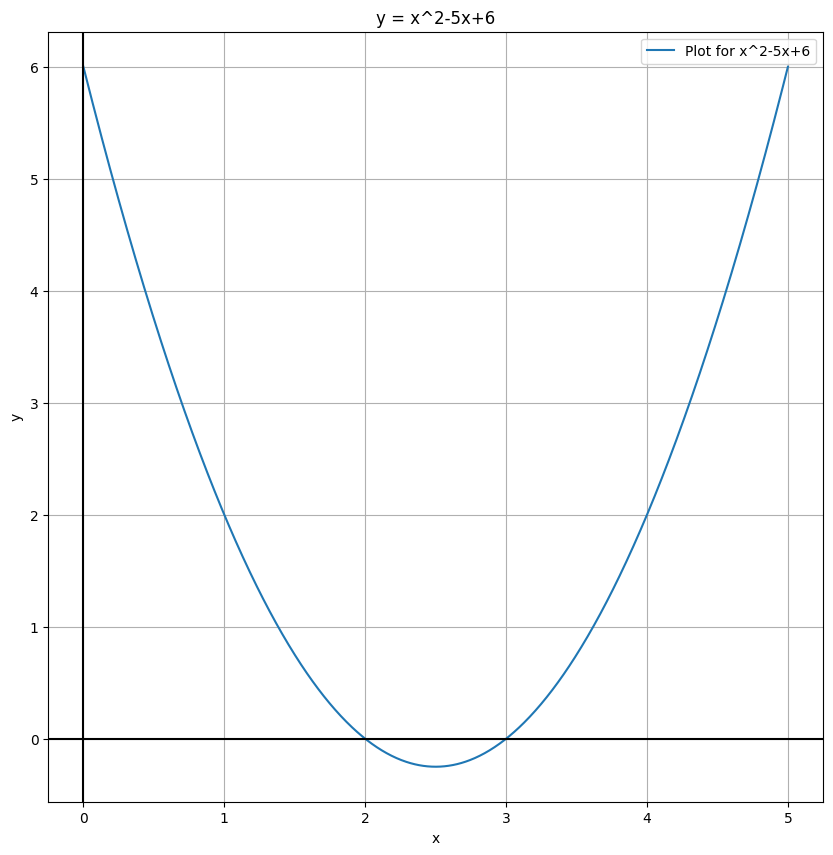

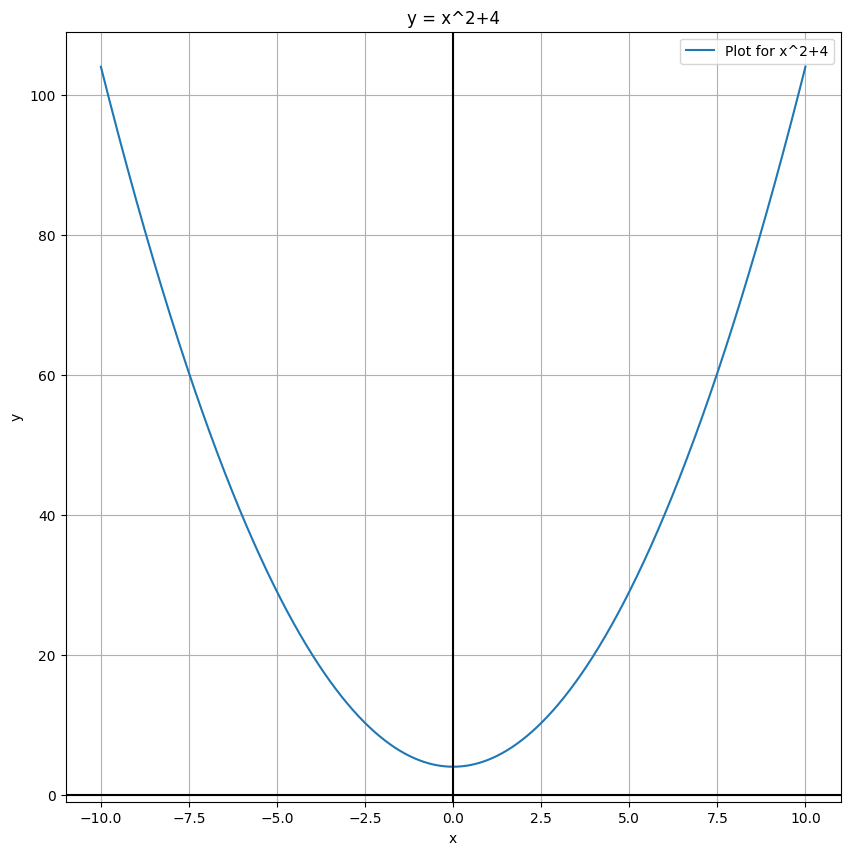

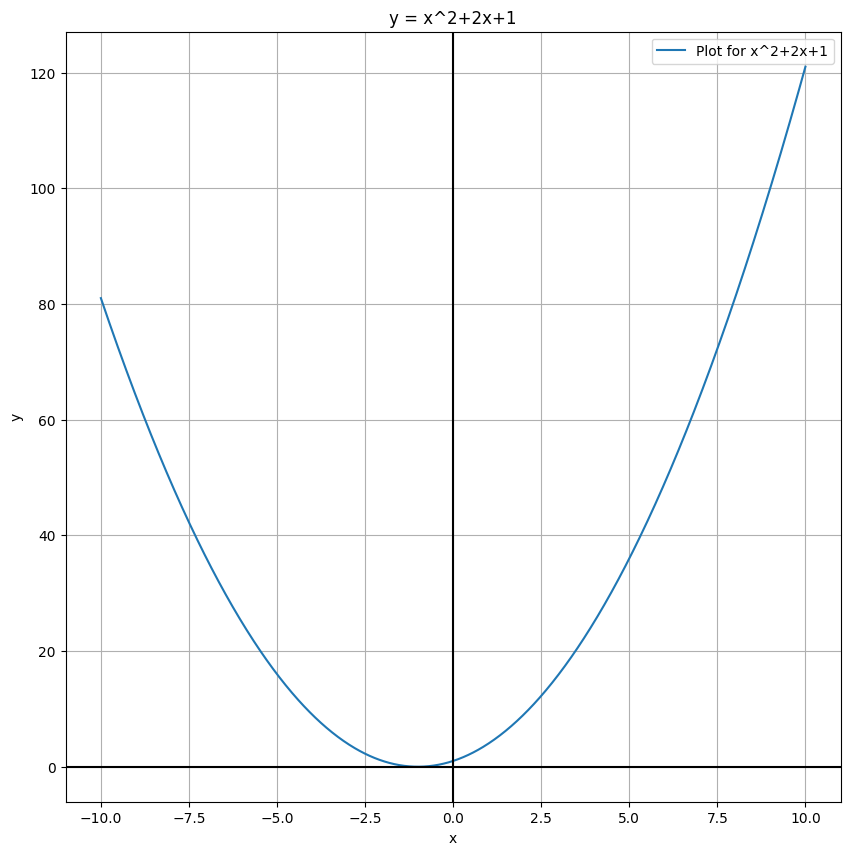

In [5]:
def plotter(coefficients, x_min, x_max, number_of_plots, polynomial_evaluator, polynomial_formatter):
  x_values = np.linspace(x_min, x_max, number_of_plots)

  y_values = polynomial_evaluator(coefficients,x_values)

  polynomial_title = polynomial_formatter(coefficients)


  plt.figure(figsize=(10, 10))
  plt.plot(x_values, y_values, label=f"Plot for {polynomial_title}")

  plt.axhline(y=0, color='k')
  plt.axvline(x=0, color='k')

  plt.xlabel("x")
  plt.ylabel("y")

  plt.title(f"y = {polynomial_title}")
  plt.grid(True)
  plt.legend()
  plt.show()


plotter(coefficients=[1,-5,6], x_min = 0, x_max = 5, number_of_plots = 1_000, polynomial_evaluator=polynomial_evaluator, polynomial_formatter=polynomial_formatter)

plotter(coefficients=[1,0,4], x_min = -10, x_max = 10, number_of_plots = 1_000, polynomial_evaluator=polynomial_evaluator, polynomial_formatter=polynomial_formatter)

plotter(coefficients=[1,2,1], x_min = -10, x_max = 10, number_of_plots = 1_000, polynomial_evaluator=polynomial_evaluator, polynomial_formatter=polynomial_formatter)

# 3. Calculating the roots

In [6]:
def calculate_roots(polynomial_input_string):

  coefficients_array = np.array(polynomial_input_string.split(), dtype = float)
  roots = np.roots(coefficients_array)
  return roots


roots = calculate_roots(polynomial_input)
roots

array([-1., -1.])

In [7]:
def root_residuals(coefficients_input_str, roots, polynomial_evaluator):
  residuals = []

  coefficients_list = [float(c) for c in coefficients_input_str.split()]
  for r in roots:
    evaluated_value = polynomial_evaluator(coefficients_list, [r])[0]
    residuals.append({"root":np.round(r,3).item(),
                      "residual": np.round(abs(evaluated_value), 3).item()})


  return residuals

root_residuals(polynomial_input, roots, polynomial_evaluator)

[{'root': -1.0, 'residual': 0.0}, {'root': -1.0, 'residual': 0.0}]

# Classifying the roots

In [8]:
def root_classifier(roots, tolerance = 1e-8):
  num_real_roots = 0
  num_complex_roots = 0


  for root in roots:
    if abs(root.imag) < 0:
      num_real_roots += 1
    else:
      num_complex_roots += 1

  return num_real_roots, num_complex_roots

root_classifier(roots)

(0, 2)

In [9]:
def repeated_roots(roots, tolerance = 1e-8):

  for idx_1 in range(len(roots)):
    for idx_2 in range(idx_1 + 1, len(roots)):
      if np.isclose(roots[idx_1], roots[idx_2], atol = tolerance, rtol = 0):
        return True

    return False

repeated_roots(roots)

True